## Setup and Dependencies

In [1]:
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf
import datetime as dt

## Model Setup

In [2]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


## Model Execution

Hyperparameters: DSGE model type, productivity calibration period, window start, window end, strategy direction, signal lag

In [54]:
class Data():
    def  __init__(self, data_length_years, window_start_in, window_end_in):
        self.data_length_years = data_length_years
        self.data_length_quarters = self.data_length_years * 4
        self.data_length_months = self.data_length_years * 12
        self.months_in_quarter = 3
        
        self.window_start_in = window_start_in
        self.window_end_in = window_end_in
        self.window_start = self.convert_str_date_to_dt(self.window_start_in)
        self.window_end = self.convert_str_date_to_dt(self.window_end_in)
        self.data_start_gdp = self.get_shifted_date(self.window_start, self.add_buffer_for_start_offset(self.data_length_months)) # Data starts 10 years prior to window start
        self.data_start_prod = self.get_shifted_date(self.data_start_gdp, self.months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
        self.data_end_prod = self.get_shifted_date(self.window_end, 3) # Data ends one quarter before window end as the final forecast must be of the window end date
        self.window_start_prod = self.get_shifted_date(self.window_start, self.months_in_quarter) # Window starts one quarter prior to GDP data for next-period forecasting

    def convert_str_date_to_dt(self, date_in):
        return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

    def get_shifted_date(self, date_input, date_offset_months, direction="backwards"):
        if direction == "backwards":
            date_offset_months *= -1
        
        shifted_date = (
            ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) + pd.tseries.offsets.DateOffset(months=date_offset_months)) 
            + pd.tseries.offsets.BMonthEnd()
        ).date()
    
        return shifted_date
    
    def add_buffer_for_start_offset(self, offset_months):
        return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

    def convert_fred_index_to_qe(self, index_dates):
        return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]
    
    # Non-farm business labor productivity index
    def pull_data_productivity(self, data_start_date=None, data_end_date=None):
        if data_start_date == None:
            data_start_date = self.data_start_prod
        if data_end_date == None:
            data_end_date = self.data_end_prod
        
        prod = pdr.DataReader("OPHNFB", "fred", start=data_start_date, end=data_end_date)
        prod_index_name = prod.index.name
        prod.index = self.convert_fred_index_to_qe(prod.index)
        prod.index.name = prod_index_name
        prod = prod.dropna()
        
        return prod

    # Real GDP
    def pull_data_gdp(self, data_start_date=None, data_end_date=None):
        if data_start_date == None:
            data_start_date = self.data_start_gdp
        if data_end_date == None:
            data_end_date = self.window_end
        
        gdp = pdr.DataReader("GDPC1", "fred", start=data_start_date, end=data_end_date)
        gdp_index_name = gdp.index.name
        gdp.index = self.convert_fred_index_to_qe(gdp.index)
        gdp.index.name = gdp_index_name
        gdp = gdp.dropna()
        
        return gdp

In [45]:
class Model(Data):
    def __init__(self, model_type, data_length_years, window_start_in, window_end_in):
        Data.__init__(self, data_length_years, window_start_in, window_end_in)
        self.model_type = model_type
        self.model = self.load_model(self.model_type)
        self.prod = self.pull_data_productivity()
        self.gdp = self.pull_data_gdp()

        self.latest_quarters_dict = {}
        self.output_forecasts_dict = {}
        self.latest_quarters_gdp_dict = {}
        self.outputs_realised_dict = {}

    def load_model(self, model_type):
        model = yaml_import(f"yamlDSGE/{model_type}.yaml")

        return model

    def generate_signals(self, 
                         window_prod_start=None, 
                         window_prod_end=None, 
                         window_gdp_start=None, 
                         window_gdp_end=None
                        ):
        if window_prod_start == None:
            window_prod_start = self.window_start_prod

        if window_prod_end == None:
            window_prod_end = self.data_end_prod

        if window_gdp_start == None:
            window_gdp_start = self.window_start

        if window_gdp_end == None:
            window_gdp_end = self.window_end

        assert len(self.prod) == len(self.gdp)

        # Update productivity and GDP data if the current range is outside the original data pull
        if (self.data_start_prod < self.prod.index[0]) & (self.data_end_prod > self.prod.index[-1]):
            self.prod = self.pull_data_productivity(self.data_start_prod, self.data_end_prod)
        if self.data_start_prod < self.prod.index[0]:
            self.prod = self.pull_data_productivity(self.data_start_prod, self.prod.index[-1])
        elif self.data_end_prod > self.prod.index[-1]:
            self.prod = self.pull_data_productivity(self.prod.index[0], self.data_end_prod)
        
        if (self.data_start_gdp < self.gdp.index[0]) & (self.window_end > self.gdp.index[-1]):
            self.gdp = self.pull_data_productivity(self.data_start_gdp, self.window_end)
        if self.data_start_gdp < self.gdp.index[0]:
            self.gdp = self.pull_data_productivity(self.data_start_gdp, self.gdp.index[-1])
        elif self.window_end > self.gdp.index[-1]:
            self.gdp = self.pull_data_productivity(self.gdp.index[0], self.window_end)
        
        prod_index_name = self.prod.index.name
        window_prod = self.prod[(self.prod.index >= window_prod_start) & (self.prod.index <= window_prod_end)]
        print("\nwindow_prod:\n")
        print(window_prod)
        
        latest_quarters = []
        output_forecasts = []
        for q in window_prod.index:
            if q in self.latest_quarters_dict.keys():
                latest_quarters.append(self.latest_quarters_dict[q])
                output_forecasts.append(self.output_forecasts_dict[q])
                print(f"Reading IRF forecast as of {q}")
            else:
                prod_data = self.prod[(self.prod.index >= self.get_shifted_date(q, self.data_length_months)) & (self.prod.index <= q)]
                assert len(prod_data.index) == self.data_length_quarters + 1
                
                prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
                # prod_cycle.plot()
                
                a_hat = prod_cycle
                a = a_hat
                a_lag = a.shift()
                
                y = a.iloc[1:]
                X = a_lag.iloc[1:].values
                
                ar1 = OLS(y.values, X).fit()
                
                rho_hat = ar1.params[0]
                print(f"Estimated rho: {rho_hat:.3f}")
            
                eps_hat = pd.Series(
                    ar1.resid,
                    index=y.index,
                    name="tfp_shock"
                )
                # eps_hat.plot()
                
                latest_quarter = eps_hat.index[-1]
                latest_shock = eps_hat.iloc[-1]
                
                print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")
            
                # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
                self.model.set_calibration(rho=rho_hat)
                # print(model.calibration.flat)
            
                #dr = time_iteration(model)
                dr = perturb(self.model, order=1)
                
                irf = response(self.model, dr, 'e_z', T=10, impulse=float(latest_shock))
                
                # plt.figure(figsize=(8,4))
                # plt.subplot(221)
                # plt.plot(irf.sel(V='z'))
                # plt.title('Productivity')
                # plt.grid()
                # plt.subplot(222)
                # plt.plot(irf.sel(V='y'))
                # plt.title('Output')
                # plt.grid()
                # plt.subplot(223)
                # plt.plot(irf.sel(V='i'))
                # plt.title('Investment')
                # plt.grid()
                # plt.subplot(224)
                # plt.plot(irf.sel(V='c'))
                # plt.title('Consumption')
                # plt.grid()
                # plt.tight_layout()
                
                irf_output = np.array(irf.sel(V='y'))
                
                irf_output = [(x - 1) for x in irf_output]
                output_forecast = irf_output[2]
                print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
                
                self.latest_quarters_dict[q] = latest_quarter
                latest_quarters.append(latest_quarter)
                self.output_forecasts_dict[q] = output_forecast
                output_forecasts.append(output_forecast)
        
        output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
        output_forecasts_ser.name = "output_forecast"
        output_forecasts_ser.index.name = prod_index_name
        output_forecasts_df = output_forecasts_ser.to_frame()
        # output_forecasts_df
        
        gdp_index_name = self.gdp.index.name
        window_gdp = self.gdp[(self.gdp.index >= window_gdp_start) & (self.gdp.index <= window_gdp_end)]
        print("\window_gdp:\n")
        print(window_gdp)
        
        latest_quarters_gdp = []
        outputs_realised = []
        for q in window_gdp.index:
            if q in self.latest_quarters_gdp_dict.keys():
                latest_quarters_gdp.append(self.latest_quarters_gdp_dict[q])
                outputs_realised.append(self.outputs_realised_dict[q])
                print(f"Reading realised value as of {q}")
            else:
                gdp_data = self.gdp[(self.gdp.index >= self.get_shifted_date(q, self.data_length_months)) & (self.gdp.index <= q)]
                assert len(gdp_data.index) == self.data_length_quarters + 1
            
                gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
                output_gap = gdp_cycle
                latest_quarter_gdp = output_gap.last_valid_index()
                output_realised = output_gap.iloc[-1]
                print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
                
                self.latest_quarters_gdp_dict[q] = latest_quarter_gdp
                latest_quarters_gdp.append(latest_quarter_gdp)
                self.outputs_realised_dict[q] = output_realised
                outputs_realised.append(output_realised)
        
        outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
        outputs_realised_ser.name = "output_realised"
        outputs_realised_ser.index.name = gdp_index_name
        outputs_realised_df = outputs_realised_ser.to_frame()
        # outputs_realised_df
        
        signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
        output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
        signals = outputs_realised_df.join(output_forecasts_mod_df)
        
        def determine_pos(row, direction):
            if row["output_forecast"] > row["output_realised"]:
                pos = 1
            elif row["output_forecast"] < row["output_realised"]:
                pos = -1
            else:
                pos = 0
        
            if direction == "mr":
                pos *= -1
            
            return pos
        
        signals["pos_mom"] = signals.apply(determine_pos, axis=1, direction="mom")
        signals["pos_mr"] = signals.apply(determine_pos, axis=1, direction="mr")
        # signals

        return signals

In [ ]:
class Execution():
    def __init__():
        self.

In [46]:
rbc_10y_20240930_20250930 = Model("rbc", 10, "2024-09-30", "2025-09-30")

In [53]:
rbc_10y_20240930_20250930.prod.index[-1]

datetime.date(2025, 6, 30)

In [47]:
signals_test = rbc_10y_20240930_20250930.generate_signals()


window_prod:

             OPHNFB
DATE               
2024-06-28  114.947
2024-09-30  115.989
2024-12-31  116.394
2025-03-31  116.127
2025-06-30  117.319
Estimated rho: 0.781
Estimated TFP shock for 2024-06-28: 0.0050
10 [0.00504428]
Next period IRF forecast as of 2024-06-28: 0.00160
Estimated rho: 0.780
Estimated TFP shock for 2024-09-30: 0.0055
10 [0.00546975]
Next period IRF forecast as of 2024-09-30: 0.00216
Estimated rho: 0.787
Estimated TFP shock for 2024-12-31: 0.0005
10 [0.00052244]
Next period IRF forecast as of 2024-12-31: -0.00427
Estimated rho: 0.779
Estimated TFP shock for 2025-03-31: -0.0053
10 [-0.00533108]
Next period IRF forecast as of 2025-03-31: -0.01182
Estimated rho: 0.771
Estimated TFP shock for 2025-06-30: 0.0054
10 [0.00539829]
Next period IRF forecast as of 2025-06-30: 0.00210
\window_gdp:

                GDPC1
DATE                 
2024-09-30  23478.570
2024-12-31  23586.542
2025-03-31  23548.210
2025-06-30  23770.976
2025-09-30  24026.834
Current period rea

In [48]:
signals_test

,output_realised,output_forecast,pos_mom,pos_mr
DATE,,,,
2024-09-30,0.003100,0.001605,-1,1
2024-12-31,0.000410,0.002162,1,-1
2025-03-31,-0.006721,-0.004268,1,-1
2025-06-30,-0.003433,-0.011824,-1,1
2025-09-30,0.000310,0.002099,1,-1


In [36]:
data_10y_20240930_20250930 = Data(10, "2024-09-30", "2025-09-30")

In [20]:
class Model():
    def __init__(self, model_type, data_length_years, window_start_in, window_end_in):
        self.model_type = model_type
        self.data_length_years = data_length_years
        self.data_length_quarters = self.data_length_years * 4
        self.data_length_months = self.data_length_years * 12
        self.months_in_quarter = 3
        
        self.window_start_in = window_start_in
        self.window_end_in = window_end_in
        self.window_start = self.convert_str_date_to_dt(self.window_start_in)
        self.window_end = self.convert_str_date_to_dt(self.window_end_in)
        self.data_start_gdp = self.get_shifted_date(self.window_start, self.add_buffer_for_start_offset(self.data_length_months)) # Data starts 10 years prior to window start
        self.data_start_prod = self.get_shifted_date(self.data_start_gdp, self.months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
        self.data_end_prod = self.get_shifted_date(self.window_end, 3) # Data ends one quarter before window end as the final forecast must be of the window end date
        self.window_start_prod = self.get_shifted_date(self.window_start, self.months_in_quarter) # Window starts one quarter prior to GDP data for next-period forecasting

        self.model = self.load_model(self.model_type)
        self.prod = self.pull_data_productivity()
        self.gdp = self.pull_data_gdp()

        self.latest_quarters_dict = {}
        self.output_forecasts_dict = {}
        self.latest_quarters_gdp_dict = {}
        self.outputs_realised_dict = {}
        
    def load_model(self, model_type):
        model = yaml_import(f"yamlDSGE/{model_type}.yaml")

        return model

    def convert_str_date_to_dt(self, date_in):
        return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

    def get_shifted_date(self, date_input, date_offset_months, direction="backwards"):
        if direction == "backwards":
            date_offset_months *= -1
        
        shifted_date = (
            ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) + pd.tseries.offsets.DateOffset(months=date_offset_months)) 
            + pd.tseries.offsets.BMonthEnd()
        ).date()
    
        return shifted_date
    
    def add_buffer_for_start_offset(self, offset_months):
        return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

    def convert_fred_index_to_qe(self, index_dates):
        return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]
    
    # Non-farm business labor productivity index
    def pull_data_productivity(self):
        prod = pdr.DataReader("OPHNFB", "fred", start=self.data_start_prod, end=self.data_end_prod)
        prod_index_name = prod.index.name
        prod.index = self.convert_fred_index_to_qe(prod.index)
        prod.index.name = prod_index_name
        prod = prod.dropna()
        
        return prod

    # Real GDP
    def pull_data_gdp(self):
        gdp = pdr.DataReader("GDPC1", "fred", start=self.data_start_gdp, end=self.window_end)
        gdp_index_name = gdp.index.name
        gdp.index = self.convert_fred_index_to_qe(gdp.index)
        gdp.index.name = gdp_index_name
        gdp = gdp.dropna()
        
        return gdp

    def generate_signals(self, 
                         window_prod_start=None, 
                         window_prod_end=None, 
                         window_gdp_start=None, 
                         window_gdp_end=None
                        ):
        if window_prod_start == None:
            window_prod_start = self.window_start_prod

        if window_prod_end == None:
            window_prod_end = self.data_end_prod

        if window_gdp_start == None:
            window_gdp_start = self.window_start

        if window_gdp_end == None:
            window_gdp_end = self.window_end

        assert len(self.prod) == len(self.gdp)
        
        prod_index_name = self.prod.index.name
        window_prod = self.prod[(self.prod.index >= window_prod_start) & (self.prod.index <= window_prod_end)]
        print("\nwindow_prod:\n")
        print(window_prod)
        
        latest_quarters = []
        output_forecasts = []
        for q in window_prod.index:
            if q in self.latest_quarters_dict.keys():
                latest_quarters.append(self.latest_quarters_dict[q])
                output_forecasts.append(self.output_forecasts_dict[q])
                print(f"Reading IRF forecast as of {q}")
            else:
                prod_data = self.prod[(self.prod.index >= self.get_shifted_date(q, self.data_length_months)) & (self.prod.index <= q)]
                assert len(prod_data.index) == self.data_length_quarters + 1
                
                prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
                # prod_cycle.plot()
                
                a_hat = prod_cycle
                a = a_hat
                a_lag = a.shift()
                
                y = a.iloc[1:]
                X = a_lag.iloc[1:].values
                
                ar1 = OLS(y.values, X).fit()
                
                rho_hat = ar1.params[0]
                print(f"Estimated rho: {rho_hat:.3f}")
            
                eps_hat = pd.Series(
                    ar1.resid,
                    index=y.index,
                    name="tfp_shock"
                )
                # eps_hat.plot()
                
                latest_quarter = eps_hat.index[-1]
                latest_shock = eps_hat.iloc[-1]
                
                print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")
            
                # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
                self.model.set_calibration(rho=rho_hat)
                # print(model.calibration.flat)
            
                #dr = time_iteration(model)
                dr = perturb(self.model, order=1)
                
                irf = response(self.model, dr, 'e_z', T=10, impulse=float(latest_shock))
                
                # plt.figure(figsize=(8,4))
                # plt.subplot(221)
                # plt.plot(irf.sel(V='z'))
                # plt.title('Productivity')
                # plt.grid()
                # plt.subplot(222)
                # plt.plot(irf.sel(V='y'))
                # plt.title('Output')
                # plt.grid()
                # plt.subplot(223)
                # plt.plot(irf.sel(V='i'))
                # plt.title('Investment')
                # plt.grid()
                # plt.subplot(224)
                # plt.plot(irf.sel(V='c'))
                # plt.title('Consumption')
                # plt.grid()
                # plt.tight_layout()
                
                irf_output = np.array(irf.sel(V='y'))
                
                irf_output = [(x - 1) for x in irf_output]
                output_forecast = irf_output[2]
                print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
                
                self.latest_quarters_dict[q] = latest_quarter
                latest_quarters.append(latest_quarter)
                self.output_forecasts_dict[q] = output_forecast
                output_forecasts.append(output_forecast)
        
        output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
        output_forecasts_ser.name = "output_forecast"
        output_forecasts_ser.index.name = prod_index_name
        output_forecasts_df = output_forecasts_ser.to_frame()
        # output_forecasts_df
        
        gdp_index_name = self.gdp.index.name
        window_gdp = self.gdp[(self.gdp.index >= window_gdp_start) & (self.gdp.index <= window_gdp_end)]
        print("\window_gdp:\n")
        print(window_gdp)
        
        latest_quarters_gdp = []
        outputs_realised = []
        for q in window_gdp.index:
            if q in self.latest_quarters_gdp_dict.keys():
                latest_quarters_gdp.append(self.latest_quarters_gdp_dict[q])
                outputs_realised.append(self.outputs_realised_dict[q])
                print(f"Reading realised value as of {q}")
            else:
                gdp_data = self.gdp[(self.gdp.index >= self.get_shifted_date(q, self.data_length_months)) & (self.gdp.index <= q)]
                assert len(gdp_data.index) == self.data_length_quarters + 1
            
                gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
                output_gap = gdp_cycle
                latest_quarter_gdp = output_gap.last_valid_index()
                output_realised = output_gap.iloc[-1]
                print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
                
                self.latest_quarters_gdp_dict[q] = latest_quarter_gdp
                latest_quarters_gdp.append(latest_quarter_gdp)
                self.outputs_realised_dict[q] = output_realised
                outputs_realised.append(output_realised)
        
        outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
        outputs_realised_ser.name = "output_realised"
        outputs_realised_ser.index.name = gdp_index_name
        outputs_realised_df = outputs_realised_ser.to_frame()
        # outputs_realised_df
        
        signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
        output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
        signals = outputs_realised_df.join(output_forecasts_mod_df)
        
        def determine_pos(row, direction):
            if row["output_forecast"] > row["output_realised"]:
                pos = 1
            elif row["output_forecast"] < row["output_realised"]:
                pos = -1
            else:
                pos = 0
        
            if direction == "mr":
                pos *= -1
            
            return pos
        
        signals["pos_mom"] = signals.apply(determine_pos, axis=1, direction="mom")
        signals["pos_mr"] = signals.apply(determine_pos, axis=1, direction="mr")
        # signals

        return signals

In [21]:
rbc_10y_20240930_20250930 = Model("rbc", 10, "2024-09-30", "2025-09-30")

In [22]:
rbc_10y_20240930_20250930.window_start_prod

datetime.date(2024, 6, 28)

In [23]:
rbc_10y_20240930_20250930.data_end_prod

datetime.date(2025, 6, 30)

In [24]:
rbc_10y_20240930_20250930.window_start

datetime.date(2024, 9, 30)

In [25]:
rbc_10y_20240930_20250930.window_end

datetime.date(2025, 9, 30)

In [26]:
signals_test = rbc_10y_20240930_20250930.generate_signals()


window_prod:

             OPHNFB
DATE               
2024-06-28  114.947
2024-09-30  115.989
2024-12-31  116.394
2025-03-31  116.127
2025-06-30  117.319
Estimated rho: 0.781
Estimated TFP shock for 2024-06-28: 0.0050
10 [0.00504428]
Next period IRF forecast as of 2024-06-28: 0.00160
Estimated rho: 0.780
Estimated TFP shock for 2024-09-30: 0.0055
10 [0.00546975]
Next period IRF forecast as of 2024-09-30: 0.00216
Estimated rho: 0.787
Estimated TFP shock for 2024-12-31: 0.0005
10 [0.00052244]
Next period IRF forecast as of 2024-12-31: -0.00427
Estimated rho: 0.779
Estimated TFP shock for 2025-03-31: -0.0053
10 [-0.00533108]
Next period IRF forecast as of 2025-03-31: -0.01182
Estimated rho: 0.771
Estimated TFP shock for 2025-06-30: 0.0054
10 [0.00539829]
Next period IRF forecast as of 2025-06-30: 0.00210
\window_gdp:

                GDPC1
DATE                 
2024-09-30  23478.570
2024-12-31  23586.542
2025-03-31  23548.210
2025-06-30  23770.976
2025-09-30  24026.834
Current period rea

In [27]:
signals_test

,output_realised,output_forecast,pos_mom,pos_mr
DATE,,,,
2024-09-30,0.003100,0.001605,-1,1
2024-12-31,0.000410,0.002162,1,-1
2025-03-31,-0.006721,-0.004268,1,-1
2025-06-30,-0.003433,-0.011824,-1,1
2025-09-30,0.000310,0.002099,1,-1


In [28]:
signals_test_short = rbc_10y_20240930_20250930.generate_signals(
    window_prod_start=dt.date(2024, 12, 31), 
    window_prod_end=dt.date(2025, 6, 30), 
    window_gdp_start=dt.date(2025, 3, 31), 
    window_gdp_end=dt.date(2025, 9, 30)
)


window_prod:

             OPHNFB
DATE               
2024-12-31  116.394
2025-03-31  116.127
2025-06-30  117.319
Reading IRF forecast as of 2024-12-31
Reading IRF forecast as of 2025-03-31
Reading IRF forecast as of 2025-06-30
\window_gdp:

                GDPC1
DATE                 
2025-03-31  23548.210
2025-06-30  23770.976
2025-09-30  24026.834
Reading realised value as of 2025-03-31
Reading realised value as of 2025-06-30
Reading realised value as of 2025-09-30


In [29]:
signals_test_short

,output_realised,output_forecast,pos_mom,pos_mr
DATE,,,,
2025-03-31,-0.006721,-0.004268,1,-1
2025-06-30,-0.003433,-0.011824,-1,1
2025-09-30,0.000310,0.002099,1,-1


In [34]:
rbc_10y_20240930_20250930.outputs_realised_dict

{datetime.date(2024, 9, 30): 0.0031004023760790034,
 datetime.date(2024, 12, 31): 0.0004099631981659968,
 datetime.date(2025, 3, 31): -0.006720676056135133,
 datetime.date(2025, 6, 30): -0.0034325457603703313,
 datetime.date(2025, 9, 30): 0.0003104933596915771}

In [ ]:

    # def get_data_productivity(self):
        # if self.prod

In [61]:
# S&P 500
data_end_asset = get_shifted_date(window_end, 3, "forwards") + pd.tseries.offsets.DateOffset(days=1) # end date in yahoo finance query is off by 1 day
asset = yf.Ticker("^GSPC").history(start=window_start, end=data_end_asset)["Close"]

In [63]:
asset_ser = asset.copy()
asset_ser_name = asset_ser.index.name
asset_ser.index = asset_ser.index.date
asset_ser.index.name = asset_ser_name
asset_ser

Date
2024-09-30    5762.479980
2024-10-01    5708.750000
2024-10-02    5709.540039
2024-10-03    5699.939941
2024-10-04    5751.069824
                 ...     
2025-12-24    6932.049805
2025-12-26    6929.939941
2025-12-29    6905.740234
2025-12-30    6896.240234
2025-12-31    6845.500000
Name: Close, Length: 315, dtype: float64

In [91]:
asset_ret_ser = asset_ser.pct_change()
asset_ret_ser.name = "Return"
asset_ret_ser

Date
2024-09-30         NaN
2024-10-01   -0.009324
2024-10-02    0.000138
2024-10-03   -0.001681
2024-10-04    0.008970
                ...   
2025-12-24    0.003221
2025-12-26   -0.000304
2025-12-29   -0.003492
2025-12-30   -0.001376
2025-12-31   -0.007358
Name: Return, Length: 315, dtype: float64

In [123]:
# Delay signals by a particular number of business days to account for lag in GDP and productivity data availability
cal_us = USFederalHolidayCalendar()
holidays = cal_us.holidays(start=window_start, end=data_end_asset) # holiday date range for the window considered for the country linked to the asset

signals_shifted_date = signals.copy()
signals_shifted_date.index += pd.offsets.CustomBusinessDay(n=14, holidays=holidays)
signals_shifted_date

,output_realised,output_forecast,pos_mom,pos_mr
DATE,,,,
2024-10-21,0.003100,0.001605,-1,1
2025-01-22,0.000410,0.002162,1,-1
2025-04-18,-0.006721,-0.004268,1,-1
2025-07-21,-0.003433,-0.011824,-1,1
2025-10-21,0.000310,0.002099,1,-1


In [124]:
asset_ret_df = asset_ret_ser.to_frame()
asset_ret_df = asset_ret_df.join(signals_shifted_date[["pos_mom", "pos_mr"]]).ffill().fillna(0)
asset_ret_df.head(20)

,Return,pos_mom,pos_mr
Date,,,
2024-09-30,0.000000,0.0,0.0
2024-10-01,-0.009324,0.0,0.0
2024-10-02,0.000138,0.0,0.0
2024-10-03,-0.001681,0.0,0.0
2024-10-04,0.008970,0.0,0.0
2024-10-07,-0.009586,0.0,0.0
2024-10-08,0.009689,0.0,0.0
2024-10-09,0.007113,0.0,0.0
2024-10-10,-0.002070,0.0,0.0


In [125]:
asset_ret_lagged_df = asset_ret_df[["pos_mom", "pos_mr"]].shift()
pnl = asset_ret_df[["Return"]].join(asset_ret_lagged_df).fillna(0)
pnl['pnl_mom'] = pnl["Return"] * pnl["pos_mom"]
pnl['pnl_mr'] = pnl["Return"] * pnl["pos_mr"]
pnl.head(20)

,Return,pos_mom,pos_mr,pnl_mom,pnl_mr
Date,,,,,
2024-09-30,0.000000,0.0,0.0,0.000000,0.000000
2024-10-01,-0.009324,0.0,0.0,-0.000000,-0.000000
2024-10-02,0.000138,0.0,0.0,0.000000,0.000000
2024-10-03,-0.001681,0.0,0.0,-0.000000,-0.000000
2024-10-04,0.008970,0.0,0.0,0.000000,0.000000
2024-10-07,-0.009586,0.0,0.0,-0.000000,-0.000000
2024-10-08,0.009689,0.0,0.0,0.000000,0.000000
2024-10-09,0.007113,0.0,0.0,0.000000,0.000000
2024-10-10,-0.002070,0.0,0.0,-0.000000,-0.000000


<Axes: xlabel='Date'>

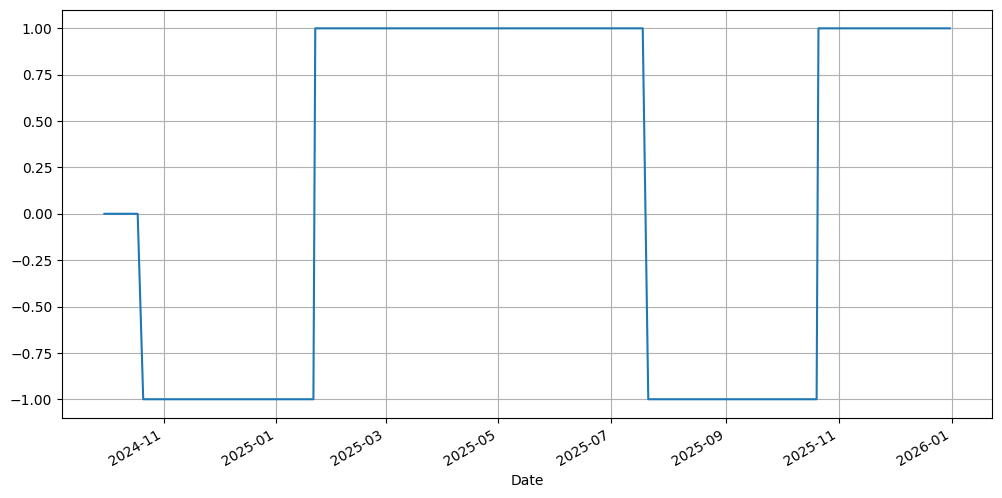

In [126]:
asset_ret_df["pos_mom"].plot(figsize=(12, 6), grid=True)

<Axes: xlabel='Date'>

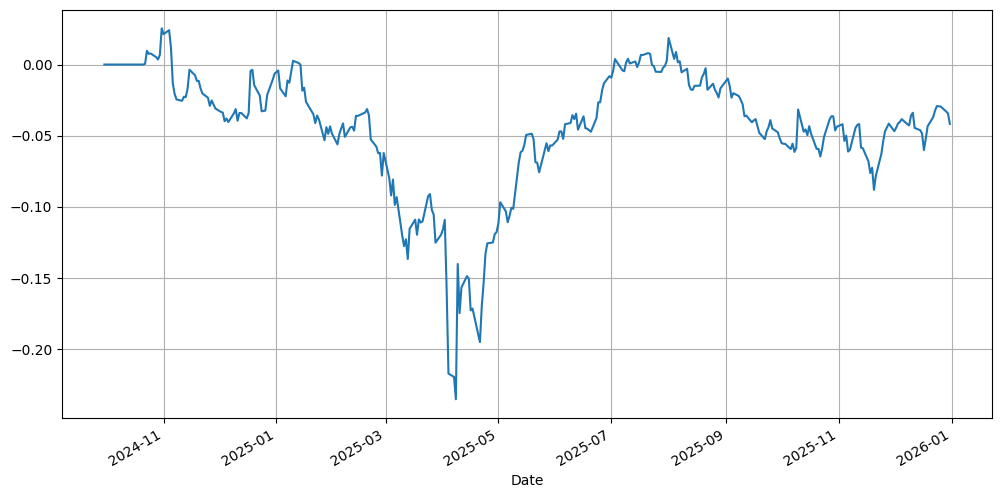

In [127]:
pnl["pnl_mom"].cumsum().plot(figsize=(12, 6), grid=True)

In [128]:
pnl["pnl_mom"].cumsum().sum()

-14.195971611882896

In [135]:
pnl_mom_mean = pnl["pnl_mom"].mean()
pnl_mom_mean

-0.00013249600618833762

In [136]:
pnl_mom_std = pnl["pnl_mom"].std()
pnl_mom_std

0.011032713362497925

In [138]:
sr_mom = pnl_mom_mean / pnl_mom_std
sr_mom

-0.012009376282602804

In [139]:
pnl["pnl_mr"].cumsum().sum()

14.195971611882896

In [140]:
pnl_mr_mean = pnl["pnl_mr"].mean()
pnl_mr_mean

0.00013249600618833762

In [141]:
pnl_mr_std = pnl["pnl_mr"].std()
pnl_mr_std

0.011032713362497925

In [142]:
sr_mr = pnl_mr_mean / pnl_mr_std
sr_mr

0.012009376282602804